# 05 - Evaluation

This notebook compares model outputs and translates metrics into project findings. It uses the CSV files saved by Notebook 04.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"

## Load Model Results

In [2]:
clustering_metrics = pd.read_csv(OUTPUT_DIR / "clustering_metrics.csv")
cluster_profile = pd.read_csv(OUTPUT_DIR / "cluster_profile.csv")
regression_metrics = pd.read_csv(OUTPUT_DIR / "regression_metrics.csv")
classification_metrics = pd.read_csv(OUTPUT_DIR / "classification_metrics.csv")
anomaly_results = pd.read_csv(OUTPUT_DIR / "anomaly_results.csv", parse_dates=["datetime"])
pca_summary = pd.read_csv(OUTPUT_DIR / "pca_summary.csv")

display(clustering_metrics)
display(cluster_profile)
display(regression_metrics)
display(classification_metrics)

,algorithm,clusters,silhouette,noise_points
0,K-Means,2,0.260062,NaN
1,K-Means,3,0.203563,NaN
2,K-Means,4,0.216276,NaN
3,K-Means,5,0.226291,NaN
4,DBSCAN,6,0.118303,2334.0


,kmeans_cluster,global_active_power,global_intensity,sub_metering_total_wh,unmetered_energy_wh,hour,is_weekend,records
0,0,0.698,2.984,279.624,417.986,10.630,0.000,10065
1,1,0.783,3.351,287.152,495.871,10.204,1.000,3821
2,2,2.593,10.983,1409.218,1183.356,15.327,0.327,3591


,model_name,mae,rmse,r2
0,Polynomial Ridge,0.370426,0.540849,0.632569
1,Linear Regression,0.377402,0.556446,0.611071
2,Ridge Regression,0.377411,0.556450,0.611066


,model_name,accuracy
0,Logistic Regression,0.997712
1,Random Forest,0.995709


## Clustering Evaluation

Silhouette scores measure how separated clusters are. Higher is better, but household energy behavior can be naturally overlapping because many appliance patterns happen at similar times.

Best clustering row:


,algorithm,clusters,silhouette,noise_points
0,K-Means,2,0.260062,NaN


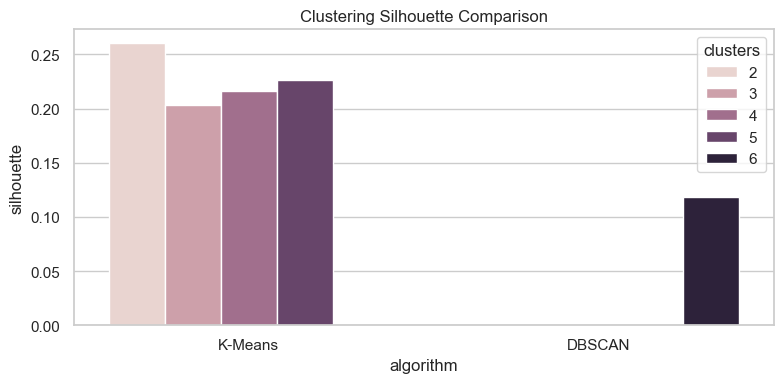

In [3]:
best_clustering = clustering_metrics.sort_values("silhouette", ascending=False).iloc[0]
print("Best clustering row:")
display(best_clustering.to_frame().T)

plt.figure(figsize=(8, 4))
sns.barplot(data=clustering_metrics, x="algorithm", y="silhouette", hue="clusters")
plt.title("Clustering Silhouette Comparison")
plt.tight_layout()
plt.show()

## Regression Evaluation

Regression is evaluated using MAE, RMSE, and R2. RMSE is useful here because it penalizes large prediction errors, which matter for energy spike prediction.

Best regression model: Polynomial Ridge


,model_name,mae,rmse,r2
0,Polynomial Ridge,0.370426,0.540849,0.632569


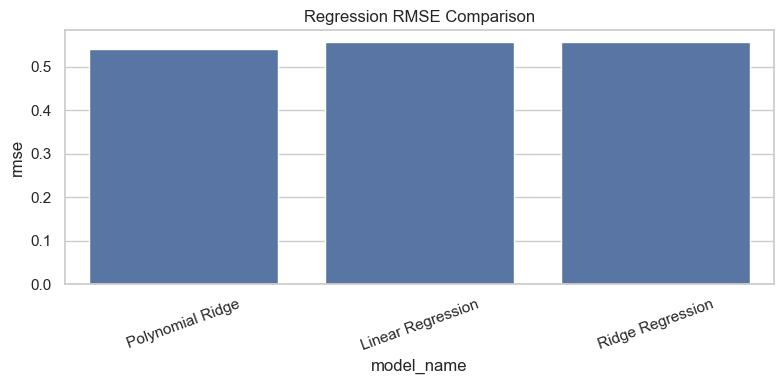

In [4]:
best_regression = regression_metrics.sort_values("rmse").iloc[0]
print("Best regression model:", best_regression["model_name"])
display(best_regression.to_frame().T)

plt.figure(figsize=(8, 4))
sns.barplot(data=regression_metrics, x="model_name", y="rmse")
plt.title("Regression RMSE Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Classification Evaluation

Classification is evaluated with accuracy and the full classification report saved by the modeling notebook.

In [5]:
best_classification = classification_metrics.sort_values("accuracy", ascending=False).iloc[0]
print("Best classification model:", best_classification["model_name"])
display(best_classification.to_frame().T)

report_text = (OUTPUT_DIR / "classification_report.txt").read_text(encoding="utf-8")
print(report_text)

Best classification model: Logistic Regression


,model_name,accuracy
0,Logistic Regression,0.997712


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2622
           1       1.00      1.00      1.00       874

    accuracy                           1.00      3496
   macro avg       1.00      1.00      1.00      3496
weighted avg       1.00      1.00      1.00      3496


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2622
           1       0.99      0.99      0.99       874

    accuracy                           1.00      3496
   macro avg       0.99      0.99      0.99      3496
weighted avg       1.00      1.00      1.00      3496



## Anomaly and PCA Evaluation

In [6]:
anomaly_share = anomaly_results["anomaly_label"].mean() * 100
print(f"Detected anomaly share: {anomaly_share:.2f}%")

top_anomalies = anomaly_results.sort_values("anomaly_score").head(10)
display(top_anomalies[["datetime", "global_active_power", "global_intensity", "anomaly_score"]])
display(pca_summary)

Detected anomaly share: 1.00%


,datetime,global_active_power,global_intensity,anomaly_score
8930,2007-12-23 19:00:00,6.488000,27.943333,-0.081439
9914,2008-02-02 19:00:00,6.496033,28.200000,-0.080651
1178,2007-02-03 19:00:00,5.814667,25.333333,-0.071808
2513,2007-03-31 10:00:00,5.161067,22.243333,-0.064317
867,2007-01-21 20:00:00,6.076567,26.323333,-0.060187
9746,2008-01-26 19:00:00,6.013800,26.160000,-0.059881
1898,2007-03-05 19:00:00,5.644900,24.116667,-0.059622
1636,2007-02-22 21:00:00,6.363867,27.703333,-0.059530
16993,2008-11-23 18:00:00,6.560533,28.383333,-0.056268
529,2007-01-07 18:00:00,5.211533,22.620000,-0.055932


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.326836,0.326836
1,PC2,0.148945,0.475781
2,PC3,0.094245,0.570027


## Final Evaluation Summary

- Clustering gives useful behavior segments, although household energy patterns overlap.
- Regression provides moderate short-term prediction performance using time and lag features.
- Classification performs strongly for high-vs-normal consumption periods.
- Anomaly detection highlights rare high-power events worth reviewing.
- The dashboard is appropriate as the deployment layer because it turns these results into interactive filters and visuals.